# Hazard Maps

In this notebook we use the AI model to generate fire hazard maps.

In [66]:
import joblib 
import geopandas as gpd 
import pandas as pd
from glob import glob 
import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import random
from matplotlib.colors import ListedColormap, BoundaryNorm


In [67]:
from utils import load_era5  

In [68]:
path = '../data'

First, we load the trained model from the previous notebook.

In [69]:
model = joblib.load(f'{path}/best_lgbm_model.joblib')

model

,num_leaves,23
,max_depth,11
,learning_rate,np.float64(0.2140922615763339)
,n_estimators,323
,min_child_samples,48
,subsample,np.float64(0.9768807022739411)
,colsample_bytree,np.float64(0.9439761626945282)
,random_state,42
,boosting_type,'gbdt'
,subsample_for_bin,200000
,objective,None


We load the area of interest and the Sentinel-2 images.

In [70]:
aoi = gpd.read_file(f"{path}/aois/seadur.geojson")
aoi

,geometry
0,"POLYGON ((-7.11185 42.54264, -6.80165 42.54264..."


In [71]:
tifs = sorted(glob(f"{path}/sentinel-2-l2a/*.tif"))
tifs_dates = [tif.split("/")[-1].split("_")[0].split(".")[0] for tif in tifs]

tifs_dates

['2025-08-01',
 '2025-08-06',
 '2025-08-11',
 '2025-08-13',
 '2025-08-16',
 '2025-08-21',
 '2025-08-23',
 '2025-08-26',
 '2025-08-31']

We now load the ERA5 variables required by the model for the specific dates and area of interest.

In [72]:
era5 = load_era5(
    aoi=aoi,
    start_date="2025-07-25",
    end_date="2025-08-31",
    dataset="reanalysis-era5-single-levels-v0",
    era5_vars=["t2m"],
)

t2m_daily = era5["t2m"].groupby(era5.valid_time.dt.floor("D")).mean("valid_time")
t2m_daily = t2m_daily[:-1, :, :]
t2m_daily = t2m_daily.rename({"floor": "valid_time"}).compute()

Run inference on the model to generate hazard maps.

In [73]:
T2M_LOOKBACK_DAYS = 5

dates = pd.date_range("2025-08-01", "2025-08-31")
dates = dates.strftime("%Y-%m-%d")
batch_size = 30000

In [74]:
for date in dates:
    print(date)
    # Find the closest tif in the past (on or before the date)
    date_dt = pd.to_datetime(date)
    tifs_dates_dt = pd.to_datetime(tifs_dates)
    idx_past = [i for i, d in enumerate(tifs_dates_dt) if d <= date_dt]
    if idx_past:
        idx = max(idx_past, key=lambda i: tifs_dates_dt[i])
        closes_tif = tifs[idx]
    else:
        closes_tif = None  # Or handle case where there is no previous tif
    # print(closes_tif)
    ds = rio.open(closes_tif)
    red, nir = ds.read(3), ds.read(4)
    ndvi = (nir.astype(float) - red.astype(float)) / (nir.astype(float) + red.astype(float))
    # print(ndvi.shape)
    height, width = ndvi.shape
    risk_flat = np.full(height * width, np.nan, dtype=np.float32)
    total_batches = len(risk_flat) // batch_size + 1
    date = pd.to_datetime(date)
    ndvi = ndvi.reshape(-1)

    def process_batch(i):
        batch_len = min(batch_size, len(risk_flat) - i * batch_size)
        _ndvi = ndvi[i * batch_size:(i + 1) * batch_size]
        table = {
            "ndvi": _ndvi,
            't2m_1': t2m_daily.sel(valid_time=date - pd.Timedelta(days=5)).values.reshape(-1).repeat(len(_ndvi)),
            't2m_2': t2m_daily.sel(valid_time=date - pd.Timedelta(days=4)).values.reshape(-1).repeat(len(_ndvi)),
            't2m_3': t2m_daily.sel(valid_time=date - pd.Timedelta(days=3)).values.reshape(-1).repeat(len(_ndvi)),
            't2m_4': t2m_daily.sel(valid_time=date - pd.Timedelta(days=2)).values.reshape(-1).repeat(len(_ndvi)),
            't2m_5': t2m_daily.sel(valid_time=date - pd.Timedelta(days=1)).values.reshape(-1).repeat(len(_ndvi)),
        }
        X = pd.DataFrame(table)
        # Use predict_proba to get probability for positive class (e.g., class 1)
        proba = model.predict_proba(X)[:, 1]  # Probability of class 1
        return (i * batch_size, i * batch_size + batch_len, proba)

    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(process_batch, i) for i in range(total_batches)]
        for f in tqdm(as_completed(futures), total=total_batches, desc="Processing batches"):
            start_idx, end_idx, proba = f.result()
            risk_flat[start_idx:end_idx] = proba
    risk = risk_flat.reshape(height, width)
    transform = ds.transform
    crs = ds.crs
    out_risk_tif = f"{path}/risk_maps/{date.strftime('%Y-%m-%d')}.tif"
    with rio.open(
        out_risk_tif,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype=risk.dtype,
        crs=crs,
        transform=transform,
    ) as dst:
        dst.write(risk, 1)


2025-08-01


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 53.90it/s]


2025-08-02


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 55.15it/s]


2025-08-03


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 57.83it/s]


2025-08-04


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 58.15it/s]


2025-08-05


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 61.41it/s]


2025-08-06


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 57.92it/s]


2025-08-07


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 57.69it/s]


2025-08-08


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 58.29it/s]


2025-08-09


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 58.24it/s]


2025-08-10


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 57.26it/s]


2025-08-11


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 52.97it/s]


2025-08-12


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 57.22it/s]


2025-08-13


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 58.89it/s]


2025-08-14


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 56.29it/s]


2025-08-15


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 52.68it/s]


2025-08-16


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 50.91it/s]


2025-08-17


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 55.31it/s]


2025-08-18


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 56.27it/s]


2025-08-19


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 56.13it/s]


2025-08-20


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 54.05it/s]


2025-08-21


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 57.85it/s]


2025-08-22


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 52.60it/s]


2025-08-23


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 58.69it/s]


2025-08-24


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 57.75it/s]


2025-08-25


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 60.21it/s]


2025-08-26


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 59.54it/s]


2025-08-27


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 53.90it/s]


2025-08-28


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 59.41it/s]


2025-08-29


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 58.44it/s]


2025-08-30


Processing batches: 100%|██████████| 228/228 [00:04<00:00, 53.97it/s]


2025-08-31


Processing batches: 100%|██████████| 228/228 [00:03<00:00, 58.76it/s]


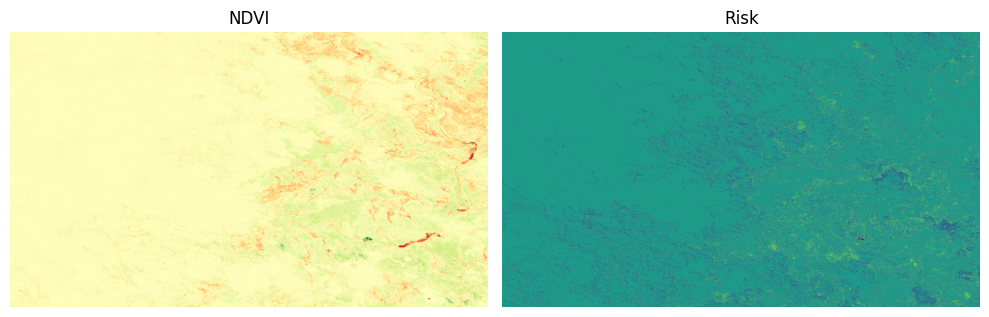

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(10, 20))

# First subplot: NDVI
axs[0].imshow(ndvi.reshape(height, width), cmap='RdYlGn')
axs[0].set_title("NDVI")
axs[0].set_axis_off()

# Second subplot: Risk
axs[1].imshow(risk)
axs[1].set_title("Risk")
axs[1].set_axis_off()

plt.tight_layout()
plt.show()


We can visualize the final maps that will be used for risk assesment.

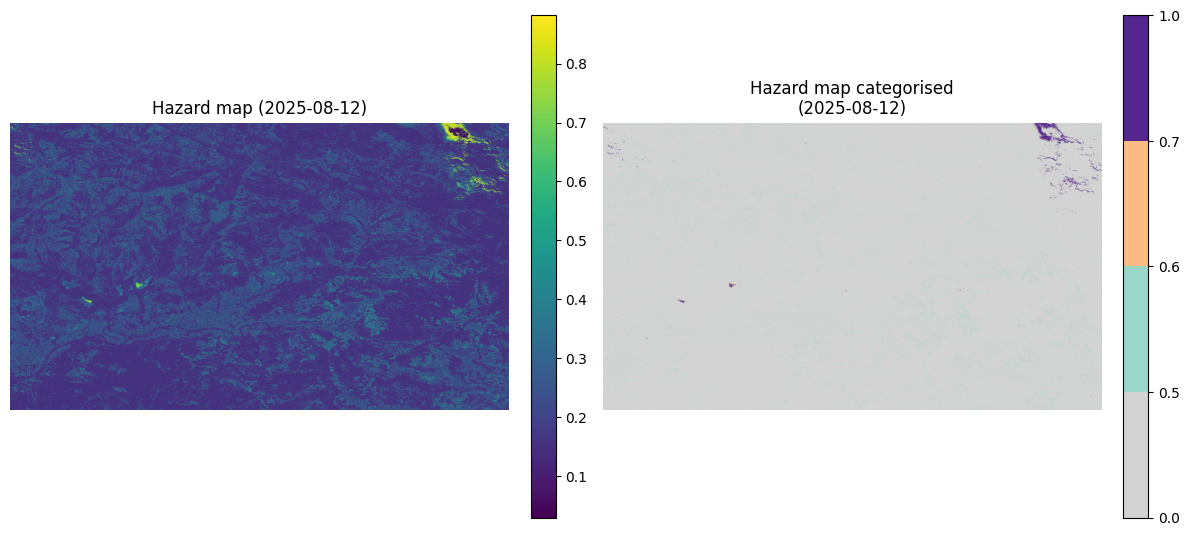

In [98]:
random_date = random.choice(dates)
risk = rio.open(f"{path}/risk_maps/{random_date}.tif").read(1)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Original risk map
im0 = axs[0].imshow(risk, cmap="viridis")
axs[0].set_title(f"Hazard map ({random_date})")
axs[0].set_axis_off()
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

# Define the bins and colors
bins = [0, 0.5, 0.6, 0.7, 1.0]
colors = ['#d3d3d3', '#99d8c9', '#fdbb84', '#54278f']  # e.g., greys, turquoise, orange, red, purple

cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, cmap.N)

# Categorised risk map
im1 = axs[1].imshow(risk, cmap=cmap, norm=norm)
axs[1].set_title(f"Hazard map categorised\n({random_date})")
axs[1].set_axis_off()
cbar = plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04, ticks=bins)
cbar.ax.set_yticklabels([f'{b:.1f}' for b in bins])

plt.tight_layout()
plt.show()
